In [4]:
import os, sys
# Ensure working directory is the repo root so asvFormula package and relative paths work correctly
if os.path.basename(os.getcwd()) == 'experiments':
    os.chdir('..')
repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

##### Imports

In [5]:
import asvFormula.bayesianNetworks.bayesianNetwork as bn
import asvFormula.experiments as exp
from asvFormula import asvRunResultsPath
from asvFormula.datasetManipulation import *
import asvFormula.ASV as exact
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

cancerExactASVFile = asvRunResultsPath + "/cancerASVAndShapleyExact.csv"
childExactASVFile = asvRunResultsPath + "/childASVAndShapleyExact.csv"

seeds = list(range(100, 125)) + [12,32,53,420,5]

In [3]:
from importlib import reload 
import asvFormula
import asvFormula.bayesianNetworks.bayesianNetwork as bn
import asvFormula.ASV as exact

bn = reload(asvFormula.bayesianNetworks.bayesianNetwork)
exact = reload(asvFormula.ASV)


## Generating the results 

### Running ASV for Cancer bayesian network

In [4]:
if os.path.exists(cancerExactASVFile):
    os.remove(cancerExactASVFile) #Remove the file to reset results
for seed in seeds:
    cancerBNmodel, variableToPredict, numberOfSamples, treeMaxDepth = exp.cancerNetworkConfig()

    BNInference, valuesPerFeature, encodedDataset, dtTreeClassifier, dtAsNetwork = initializeDataAndRemoveVariable(cancerBNmodel, variableToPredict, numberOfSamples, treeMaxDepth, seed)

    dataNoPrediction = encodedDataset.drop(variableToPredict, axis=1)
    first_instance = dataNoPrediction.iloc[0]

    asvCalc = exact.ASV(cancerBNmodel, dtTreeClassifier, BNInference, valuesPerFeature, variableToPredict, predictionFunction='Exact')

    exp.writeASVAndShapleyIntoFile(first_instance, dataNoPrediction, dtTreeClassifier, asvCalc, cancerExactASVFile , valuesPerFeature, variableToPredict, seed)

### Running ASV for Child bayesian network

In [5]:
if os.path.exists(childExactASVFile):
    os.remove(childExactASVFile) #Remove the file to reset results
for seed in seeds:
    treeBNChild, variableToPredict, numberOfSamples, treeMaxDepth = exp.childNetworkConfig()

    BNInference, valuesPerFeature, encodedDataset, dtTreeClassifier, dtAsNetwork = initializeDataAndRemoveVariable(treeBNChild, variableToPredict, numberOfSamples, treeMaxDepth, seed)

    dataNoPrediction = encodedDataset.drop(variableToPredict, axis=1)
    first_instance = dataNoPrediction.iloc[0]

    asvCalc = exact.ASV(treeBNChild, dtTreeClassifier, BNInference, valuesPerFeature, variableToPredict, predictionFunction='Exact')

    exp.writeASVAndShapleyIntoFile(first_instance, dataNoPrediction, dtTreeClassifier, asvCalc, childExactASVFile , valuesPerFeature, variableToPredict, seed)
    #This takes 5 minutes per seed to run

#Running this in parallel with the approximate ASV takes around 20 minuts each

## Plotting the results 

### Plotting the networks and their CPTS

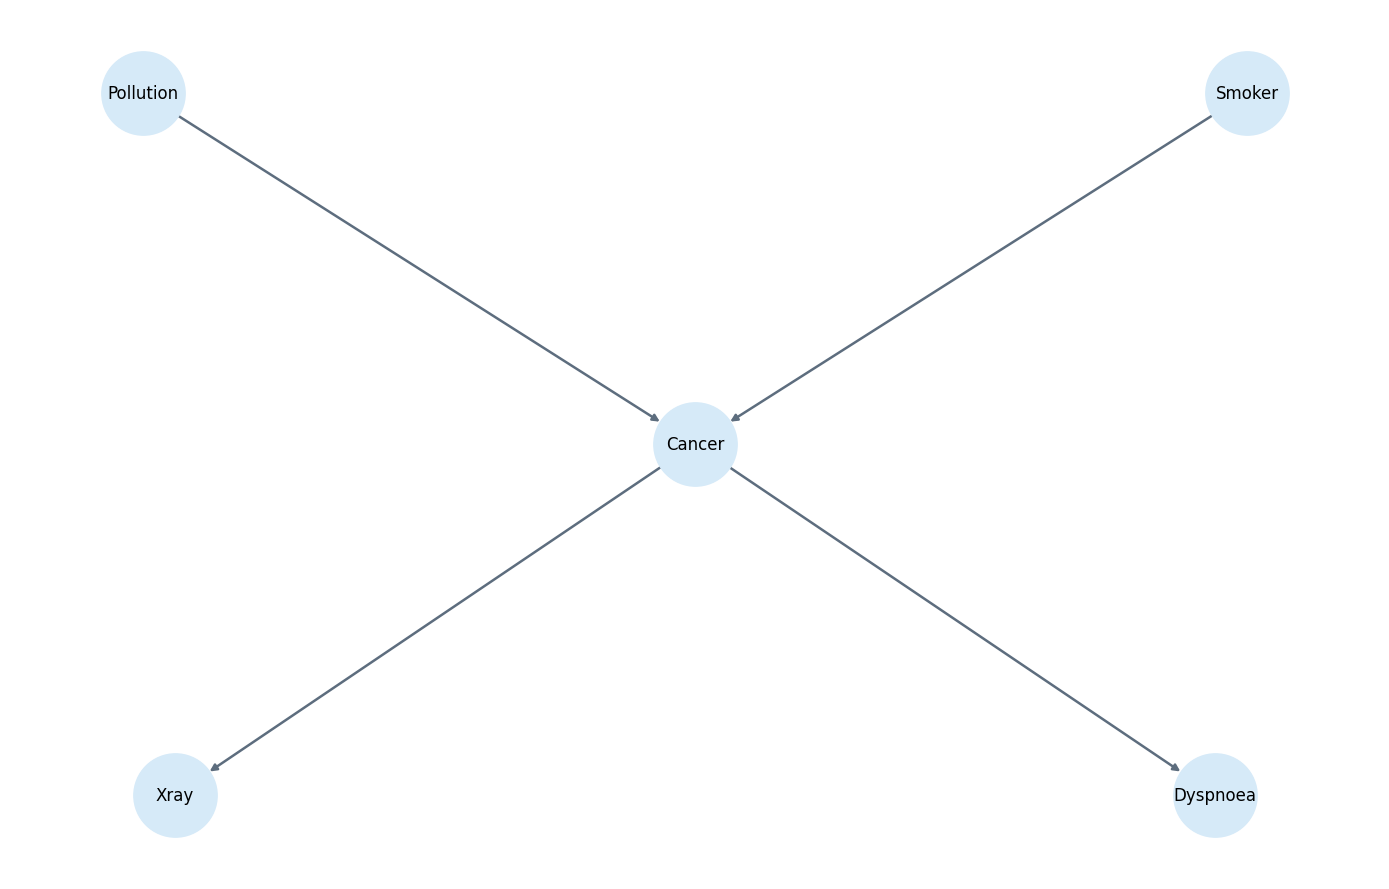

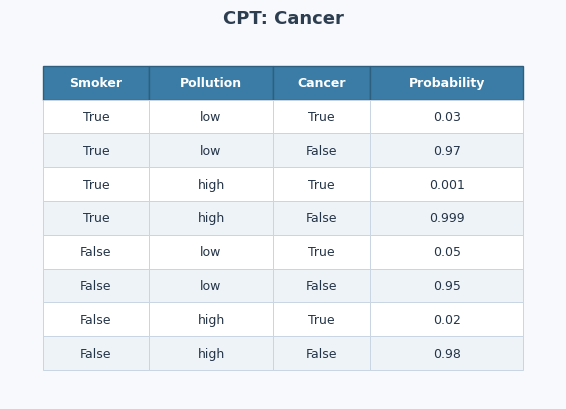

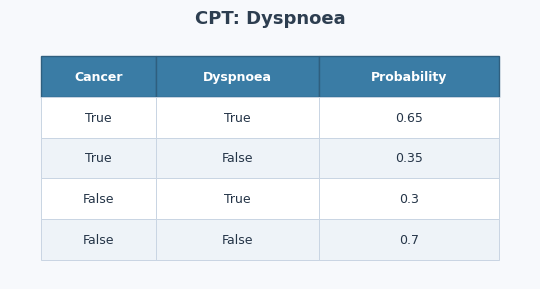

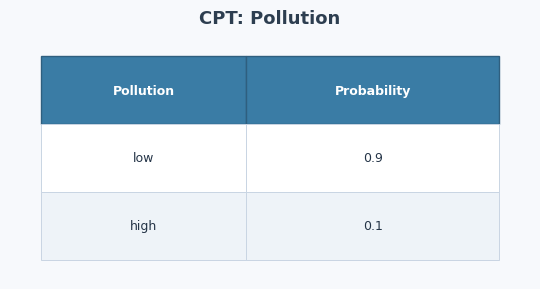

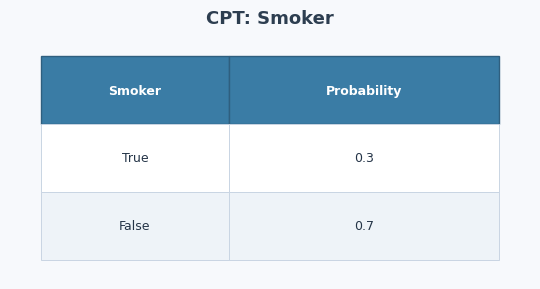

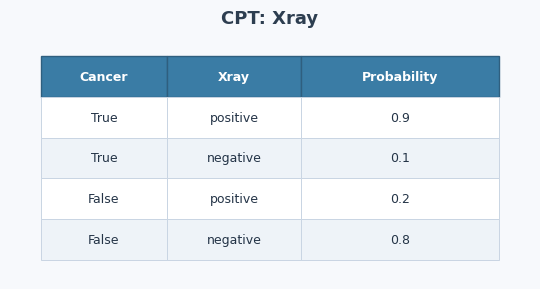

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import itertools
import pandas as pd
from asvFormula.bayesianNetworks.bayesianNetwork import bayesianNetworkToDigraph

def plot_bn_and_cpts(model, title="Bayesian Network", x_spacing=2.2, y_spacing=1.5):
    # 1) Plot only the DAG with larger nodes.
    G = bayesianNetworkToDigraph(model)

    fig, ax = plt.subplots(figsize=(14, 9))

    try:
        pos = nx.nx_agraph.graphviz_layout(
            G,
            prog="dot",
            args="-Granksep=1.2 -Gnodesep=1.0"
        )
    except Exception:
        pos = nx.spring_layout(G, seed=42, k=1.4, iterations=250)

    # Explicit coordinate stretching so spacing is visibly larger.
    pos = {node: (x * x_spacing, y * y_spacing) for node, (x, y) in pos.items()}

    nx.draw(
        G, pos,
        with_labels=True,
        node_size=3600,
        node_color="#d6eaf8",
        edge_color="#5d6d7e",
        font_size=12,
        arrows=True,
        width=1.8,
        ax=ax
    )

    # Manual margins to avoid clipping after stretching.
    xs = np.array([p[0] for p in pos.values()])
    ys = np.array([p[1] for p in pos.values()])
    xpad = max(1.0, 0.12 * (xs.max() - xs.min() + 1e-9))
    ypad = max(1.0, 0.12 * (ys.max() - ys.min() + 1e-9))
    ax.set_xlim(xs.min() - xpad, xs.max() + xpad)
    ax.set_ylim(ys.min() - ypad, ys.max() + ypad)

    ax.axis("off")
    plt.tight_layout()
    plt.show()

    # 2) Plot each CPT as a separate styled table figure.
    for cpd in model.get_cpds():
        df = cpd_to_dataframe_compat(cpd).round(4)

        # Estimate figure width from text length, keeping compact output.
        col_max_chars = []
        for col_name in df.columns:
            values_len = [len(str(v)) for v in df[col_name].tolist()]
            max_len = max([len(str(col_name))] + values_len)
            col_max_chars.append(max_len)

        total_chars = max(1, sum(col_max_chars))
        fig_w = min(11, max(5.5, 0.18 * total_chars))
        fig_h = max(3, 0.42 * (len(df) + 2))
        fig, t_ax = plt.subplots(figsize=(fig_w, fig_h))
        t_ax.axis("off")

        # Soft card-like background.
        fig.patch.set_facecolor("#f7f9fc")
        t_ax.set_facecolor("#f7f9fc")
        t_ax.set_title(f"CPT: {cpd.variable}", fontsize=13, fontweight="bold", color="#2d3e50", pad=10)

        table = t_ax.table(
            cellText=df.values,
            colLabels=df.columns,
            loc="center",
            cellLoc="center",
            bbox=[0.06, 0.08, 0.88, 0.84]
        )
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1.0, 1.25)

        # Let matplotlib size each column to fit its content (header + values).
        ncols = len(df.columns)
        table.auto_set_column_width(col=list(range(ncols)))

        # Style header and body cells.
        for (r, c), cell in table.get_celld().items():
            if r == 0:
                cell.set_facecolor("#3a7ca5")
                cell.set_text_props(color="white", weight="bold")
                cell.set_edgecolor("#2f5f7f")
                cell.set_linewidth(1.0)
                cell.PAD = 0.08
            else:
                # Zebra stripes for readability.
                if r % 2 == 0:
                    cell.set_facecolor("#eef3f8")
                else:
                    cell.set_facecolor("#ffffff")
                cell.set_text_props(color="#243447")
                cell.set_edgecolor("#c9d5e3")
                cell.set_linewidth(0.7)
                cell.PAD = 0.05

        plt.tight_layout()
        plt.show()

def cpd_to_dataframe_compat(cpd):

    # Older pgmpy fallback
    var = cpd.variable
    state_names = getattr(cpd, "state_names", {}) or {}

    var_states = state_names.get(var, list(range(cpd.variable_card)))
    evidence = list(cpd.get_evidence() or [])

    # Keep evidence order consistent with get_values() columns
    evidence_cards = []
    for ev in evidence:
        if ev in state_names:
            evidence_cards.append(len(state_names[ev]))
        else:
            ev_cpd = cpd
            evidence_cards.append(
                getattr(ev_cpd, "cardinality", [])[evidence.index(ev) + 1]
                if hasattr(ev_cpd, "cardinality") else 0
            )

    values = cpd.get_values()
    rows = []

    if len(evidence) == 0:
        # Prior CPT: one probability per state
        flat_vals = values.reshape(-1)
        for i, s in enumerate(var_states):
            rows.append({var: s, "Probability": float(flat_vals[i])})
    else:
        ev_state_lists = [state_names.get(ev, list(range(card)))
                          for ev, card in zip(evidence, evidence_cards)]
        ev_combos = list(itertools.product(*ev_state_lists))

        # values shape: (variable_card, product(evidence_card))
        for col_idx, ev_vals in enumerate(ev_combos):
            for row_idx, var_state in enumerate(var_states):
                row = {ev: ev_vals[k] for k, ev in enumerate(evidence)}
                row[var] = var_state
                row["Probability"] = float(values[row_idx, col_idx])
                rows.append(row)

    return pd.DataFrame(rows)

#cancerBNmodel, variableToPredict, numberOfSamples, treeMaxDepth = exp.cancerNetworkConfig()
#treeBNChild, variableToPredict, numberOfSamples, treeMaxDepth = exp.childNetworkConfig()
plot_bn_and_cpts(cancerBNmodel, title="Cancer Bayesian Network")

### Converting to numerical data

In [8]:
dfCancerExactDict = exp.multipleSeedsDataframes(cancerExactASVFile, seeds)

dfChildExactDict = exp.multipleSeedsDataframes(childExactASVFile, seeds)

### Plotting ASV values for each feature

In [10]:
plotsResultsFolder = 'results/plots/'

def plotASVandShapForSeeds(seeds, dfDict, hueValue):
    _, axes = plt.subplots(len(seeds), 2, figsize=(20, 15))
    for i, seed in enumerate(seeds):
        df = dfDict[seed]
        exp.plotASVandShapFromDF(df, hueValue, seed, None, axes[i])

    bayesianNetwork = 'cancer' if "Smoker value" == hueValue else 'child'
    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.savefig(f"{plotsResultsFolder}{bayesianNetwork}MultipleSeedsASVandShapley.png")
    plt.show()

exp.plotASVandShapFromDF(dfCancerExactDict[12], 'Smoker value', 12, f"{plotsResultsFolder}{dfCancerExactDict[12].name}ASVAndShapley.png")
exp.plotASVandShapFromDF(dfChildExactDict[420], 'Age value', 420, f"{plotsResultsFolder}{dfChildExactDict[420].name}ASVAndShapley.png")

seeds = [12,32,53,420,5]

plotASVandShapForSeeds(seeds, dfCancerExactDict, 'Smoker value')
plotASVandShapForSeeds(seeds, dfChildExactDict, 'Age value')


## Analyzing Networks Probabilities

In [ ]:
from pgmpy.readwrite import BIFReader
from asvFormula.bayesianNetworks import networkSamplesPath
import pandas as pd
from pgmpy.inference import VariableElimination
import itertools

cancerNetworkPath = networkSamplesPath + "/cancer.bif"
completeCancerBNModel = BIFReader(cancerNetworkPath).get_model()

childNetworkPath = networkSamplesPath + "/child.bif"
completeChildBNModel = BIFReader(childNetworkPath).get_model()

In [ ]:
def possibleStatesFor(variable, bnModel):
    return bnModel.get_cpds(variable).state_names[variable]

# Function to add query results and compute differences
def add_query_rows(variable, values, variableToPredict, rows, bnModel):
    state_names = possibleStatesFor(variableToPredict, bnModel)
    probs = {state_val: {} for state_val in state_names}
    predictedProbColumn = f"phi({variableToPredict})"
    infer = VariableElimination(bnModel)

    predicted_prob = infer.query(variables=[variableToPredict])

    for val in values:
        result = infer.query(variables=[variableToPredict], evidence={variable: val})
        for i, state_val in enumerate(state_names):
            original_prob = predicted_prob.get_value(**{variableToPredict: state_val})
            prob = round(result.values[i], 4)
            probs[state_val][val] = prob

            rows.append({
                "Variable": variable,
                "Variable value" : val,
                variableToPredict: state_val,
                predictedProbColumn : prob,
                "Probability Shift" : round(abs(prob - original_prob), 4)
            })

def obtainProbabilityShifts(bnModel, variableToPredict):
    rows = []
    variables = list(bnModel.nodes)
    variables.remove(variableToPredict)
    for variable in variables:
        add_query_rows(variable, possibleStatesFor(variable, bnModel), variableToPredict, rows, bnModel)

    df = pd.DataFrame(rows)
    return df

cancerDf = obtainProbabilityShifts(completeCancerBNModel, "Smoker")
childDf = obtainProbabilityShifts(completeChildBNModel, "Age")

resultsFolder = "results/probabilityShifts/"
cancerDf.to_csv(resultsFolder + "cancerProbabilityShifts.csv")
childDf.to_csv(resultsFolder + "childProbabilityShifts.csv")



In [8]:
from pgmpy.readwrite import BIFReader
from asvFormula.bayesianNetworks import networkSamplesPath
import pandas as pd
from pgmpy.inference import VariableElimination
import itertools

cancerNetworkPath = networkSamplesPath + "/cancer.bif"
completeCancerBNModel = BIFReader(cancerNetworkPath).get_model()

childNetworkPath = networkSamplesPath + "/child.bif"
completeChildBNModel = BIFReader(childNetworkPath).get_model()

In [9]:
def possibleStatesFor(variable, bnModel):
    return bnModel.get_cpds(variable).state_names[variable]

# Function to add query results and compute differences
def add_query_rows(variable, values, variableToPredict, rows, bnModel):
    state_names = possibleStatesFor(variableToPredict, bnModel)
    probs = {state_val: {} for state_val in state_names}
    predictedProbColumn = f"phi({variableToPredict})"
    infer = VariableElimination(bnModel)

    predicted_prob = infer.query(variables=[variableToPredict])

    for val in values:
        result = infer.query(variables=[variableToPredict], evidence={variable: val})
        for i, state_val in enumerate(state_names):
            original_prob = predicted_prob.get_value(**{variableToPredict: state_val})
            prob = round(result.values[i], 4)
            probs[state_val][val] = prob

            rows.append({
                "Variable": variable,
                "Variable value" : val,
                variableToPredict: state_val,
                predictedProbColumn : prob,
                "Probability Shift" : round(abs(prob - original_prob), 4)
            })

def obtainProbabilityShifts(bnModel, variableToPredict):
    rows = []
    variables = list(bnModel.nodes)
    variables.remove(variableToPredict)
    for variable in variables:
        add_query_rows(variable, possibleStatesFor(variable, bnModel), variableToPredict, rows, bnModel)

    df = pd.DataFrame(rows)
    return df

cancerDf = obtainProbabilityShifts(completeCancerBNModel, "Smoker")
childDf = obtainProbabilityShifts(completeChildBNModel, "Age")

resultsFolder = "results/probabilityShifts/"
cancerDf.to_csv(resultsFolder + "cancerProbabilityShifts.csv")
childDf.to_csv(resultsFolder + "childProbabilityShifts.csv")



## Analyzing Pollution ASV Values

In [5]:
seed = 101
cancerBNmodel, variableToPredict, numberOfSamples, treeMaxDepth = exp.cancerNetworkConfig()
BNInference, valuesPerFeature, encodedDataset, dtTreeClassifier, dtAsNetwork = initializeDataAndRemoveVariable(cancerBNmodel, variableToPredict, numberOfSamples, treeMaxDepth, seed)

dataNoPrediction = encodedDataset.drop(variableToPredict, axis=1)
first_instance = dataNoPrediction.iloc[0]

asvCalc = exact.ASV(cancerBNmodel, dtTreeClassifier, BNInference, valuesPerFeature, variableToPredict, predictionFunction='Exact')

cancerASVTestingFile = asvRunResultsPath + "/childASVAndShapleyApproximateTesting.csv"

dataSet = dataNoPrediction.copy()
progress = False

In [6]:
drawDecisionTree(dtAsNetwork)

In [4]:
import shap

features = list(dataSet.columns)
explainer = shap.TreeExplainer(dtTreeClassifier, dataSet)
shap_values = explainer.shap_values(first_instance)
predictionValues = valuesPerFeature[variableToPredict]

cancerASVTestingFile = asvRunResultsPath + "/childASVAndShapleyApproximateTesting.csv"

# Check if the file exists to decide whether to write the header
file_exists = os.path.isfile(cancerASVTestingFile)

os.remove(cancerASVTestingFile) if file_exists else None  # Remove the file to reset results

with open(cancerASVTestingFile, 'a') as f:
    if not file_exists:
        f.write(f"Feature,{variableToPredict} value,ASV,Shapley,Seed\n")

    for i, feature in enumerate(features):
        asvValue = asvCalc.asvForFeature(feature, first_instance, showProgress=progress)
        shapleyValue = shap_values[i]
        for j in range(len(shapleyValue)):
            f.write(f"{feature},{predictionValues[j]},{asvValue[j]},{shapleyValue[j]},{seed}\n")